In [1]:
import re
import pickle
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print('TF:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

TF: 2.15.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
DATA_DIR = Path('../data')
IMG_DIR  = DATA_DIR / 'images'
PROC_DIR = Path('../data_processed')
CKPT_DIR = Path('../checkpoints')

IMG_SIZE       = 224
EMBED_DIM      = 256
TEXT_MAX_LEN   = 32
VOCAB_SIZE     = 12000           # slightly larger because more variation
BATCH_SIZE     = 64
TEMPERATURE    = 0.07

# Reduced epoch counts because we have 4x as many image-text pairs per product
BASELINE_EPOCHS = 2
BASELINE_LR     = 1e-3

FT_EPOCHS       = 2
FT_LR           = 1e-5
UNFREEZE_FROM   = -20

def make_early_stopping(patience=1):
    return tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=patience,
        restore_best_weights=True, verbose=1,
    )

In [3]:
# Re-load styles.csv to get all the attribute fields we need
df = pd.read_csv(DATA_DIR / 'styles.csv', on_bad_lines='skip')
df['image_path'] = df['id'].astype(str) + '.jpg'
df['exists'] = df['image_path'].apply(lambda p: (IMG_DIR / p).exists())
df = df[df['exists']].drop(columns=['exists']).reset_index(drop=True)

# Drop rare classes for stratification
type_counts = df['articleType'].value_counts()
df = df[df['articleType'].isin(type_counts[type_counts >= 10].index)].reset_index(drop=True)
print(f'Products: {len(df):,}')
df.head(3)

Products: 44,265


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,15970.jpg
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,39386.jpg
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,59263.jpg


In [4]:
# Naive but effective singularizer
_KEEP_PLURAL = {'jeans', 'sunglasses', 'pajamas', 'shorts', 'tights', 'leggings'}
def singularize(word):
    w = word.lower().strip()
    if w in _KEEP_PLURAL or not w.endswith('s'):
        return w
    if w.endswith('ies'):  # accessories -> accessory
        return w[:-3] + 'y'
    if w.endswith('ses') or w.endswith('shes') or w.endswith('ches'):
        return w[:-2]      # watches -> watch, dresses -> dress
    if w.endswith('ss'):
        return w           # dress
    return w[:-1]          # tshirts -> tshirt, shoes -> shoe

def safe(s):
    return str(s).strip() if pd.notna(s) and str(s).lower() != 'nan' else ''

def caption_templated(row):
    g, c, a = safe(row.get('gender')), safe(row.get('baseColour')), safe(row.get('articleType'))
    u, s, n = safe(row.get('usage')),   safe(row.get('season')),     safe(row.get('productDisplayName'))
    head = f'A {g.lower()} {c.lower()} {a.lower()}'.replace('  ', ' ').strip()
    parts = [head]
    if u: parts.append(f'for {u.lower()} wear')
    if s: parts.append(f'in {s.lower()}')
    cap = ', '.join(parts) + '.'
    if n: cap += f' {n}.'
    return cap

def caption_short(row):
    c = safe(row.get('baseColour')).lower()
    a = singularize(safe(row.get('articleType')))
    return f'{c} {a}'.strip()

def caption_shopper(row):
    g = safe(row.get('gender')).lower()
    c = safe(row.get('baseColour')).lower()
    a = singularize(safe(row.get('articleType')))
    u = safe(row.get('usage')).lower()
    g_word = {'men': "men's", 'women': "women's", 'boys': "boys'", 'girls': "girls'"}.get(g, g)
    if u and u != 'casual':
        return f'{g_word} {c} {u} {a}'.strip()
    return f'{g_word} {c} {a}'.strip()

def caption_brand(row):
    return safe(row.get('productDisplayName'))

GENERATORS = [
    ('templated', caption_templated),
    ('short',     caption_short),
    ('shopper',   caption_shopper),
    ('brand',     caption_brand),
]

# Sanity check on 3 random products
for _, row in df.sample(3, random_state=7).iterrows():
    print(f'\nProduct {row["id"]} ({row["articleType"]}):')
    for name, fn in GENERATORS:
        print(f'  [{name:9}] {fn(row)!r}')


Product 26558 (Casual Shoes):
  [templated] 'A men black casual shoes, for casual wear, in summer. Lee Cooper Men Black Shoes.'
  [short    ] 'black casual shoe'
  [shopper  ] "men's black casual shoe"
  [brand    ] 'Lee Cooper Men Black Shoes'

Product 28064 (Trunk):
  [templated] 'A men black trunk, for casual wear, in summer. Jockey ELANCE Men Black Trunk 1015.'
  [short    ] 'black trunk'
  [shopper  ] "men's black trunk"
  [brand    ] 'Jockey ELANCE Men Black Trunk 1015'

Product 3276 (Tshirts):
  [templated] "A men brown tshirts, for casual wear, in summer. Guerrilla Men's Wanted Coffee T-shirt."
  [short    ] 'brown tshirt'
  [shopper  ] "men's brown tshirt"
  [brand    ] "Guerrilla Men's Wanted Coffee T-shirt"


In [5]:
# Split product IDs first
train_prod, temp_prod = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['articleType']
)
val_prod, test_prod = train_test_split(
    temp_prod, test_size=0.5, random_state=42, stratify=temp_prod['articleType']
)
print(f'Train products: {len(train_prod):,}')
print(f'Val products:   {len(val_prod):,}')
print(f'Test products:  {len(test_prod):,}')

def expand(prod_df):
    rows = []
    for _, row in prod_df.iterrows():
        for name, fn in GENERATORS:
            cap = fn(row)
            if not cap:
                continue
            rows.append({
                'id':          row['id'],
                'image_path':  row['image_path'],
                'caption':     cap,
                'style':       name,
                'articleType': row['articleType'],
                'gender':      row['gender'],
                'baseColour':  row['baseColour'],
            })
    return pd.DataFrame(rows)

train_aug = expand(train_prod)
val_aug   = expand(val_prod)
test_aug  = expand(test_prod)

print(f'\nAugmented pairs:')
print(f'  Train: {len(train_aug):,}  ({len(train_aug)/len(train_prod):.1f}x products)')
print(f'  Val:   {len(val_aug):,}')
print(f'  Test:  {len(test_aug):,}')

# Verify no product leakage
assert len(set(train_aug['id']) & set(val_aug['id']))  == 0
assert len(set(train_aug['id']) & set(test_aug['id'])) == 0
print('No product leakage between splits.')

# Save
train_aug.to_csv(PROC_DIR / 'train_aug.csv', index=False)
val_aug.to_csv(PROC_DIR / 'val_aug.csv', index=False)
test_aug.to_csv(PROC_DIR / 'test_aug.csv', index=False)

Train products: 35,412
Val products:   4,426
Test products:  4,427

Augmented pairs:
  Train: 141,642  (4.0x products)
  Val:   17,704
  Test:  17,707
No product leakage between splits.


In [6]:
vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=TEXT_MAX_LEN,
    standardize='lower_and_strip_punctuation',
)
vectorizer.adapt(train_aug['caption'].values)
print('Vocab size:', len(vectorizer.get_vocabulary()))

2026-04-30 20:38:40.177741: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-04-30 20:38:40.177760: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-04-30 20:38:40.177767: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
2026-04-30 20:38:40.177790: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-30 20:38:40.177806: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-30 20:38:40.393675: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Vocab size: 7988


In [7]:
def load_image(path):
    raw = tf.io.read_file(path)
    img = tf.io.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return tf.cast(img, tf.float32)

def make_dataset(df, training=False):
    paths    = (str(IMG_DIR.resolve()) + '/' + df['image_path']).values
    captions = df['caption'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, captions))
    if training:
        ds = ds.shuffle(8192, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, c: (load_image(p), c), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE, drop_remainder=True)
    ds = ds.map(lambda i, c: (i, vectorizer(c)), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

class TransformerBlock(layers.Layer):
    def __init__(self, dim, heads=4, ff=256, dropout=0.1):
        super().__init__()
        self.attn = layers.MultiHeadAttention(num_heads=heads, key_dim=dim // heads)
        self.ffn  = tf.keras.Sequential([layers.Dense(ff, activation='relu'), layers.Dense(dim)])
        self.ln1, self.ln2 = layers.LayerNormalization(), layers.LayerNormalization()
        self.dropout = layers.Dropout(dropout)
    def call(self, x, training=False):
        a = self.attn(x, x, x)
        x = self.ln1(x + self.dropout(a, training=training))
        f = self.ffn(x)
        x = self.ln2(x + self.dropout(f, training=training))
        return x

def build_image_encoder():
    base = tf.keras.applications.EfficientNetB0(
        include_top=False, pooling='avg', weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x   = base(inp, training=False)
    x   = layers.Dense(512, activation='relu')(x)
    x   = layers.Dropout(0.1)(x)
    out = layers.Dense(EMBED_DIM)(x)
    return Model(inp, out, name='image_encoder'), base

def build_text_encoder(dim=128):
    inp = layers.Input(shape=(TEXT_MAX_LEN,), dtype='int64')
    tok = layers.Embedding(VOCAB_SIZE, dim, mask_zero=True)(inp)
    pos = layers.Embedding(TEXT_MAX_LEN, dim)(tf.range(TEXT_MAX_LEN))
    x   = tok + pos
    x   = TransformerBlock(dim, heads=4, ff=256)(x)
    x   = TransformerBlock(dim, heads=4, ff=256)(x)
    x   = layers.GlobalAveragePooling1D()(x)
    x   = layers.Dense(256, activation='relu')(x)
    out = layers.Dense(EMBED_DIM)(x)
    return Model(inp, out, name='text_encoder')

class DualEncoder(Model):
    def __init__(self, img_enc, txt_enc, temperature=TEMPERATURE):
        super().__init__()
        self.img_enc, self.txt_enc = img_enc, txt_enc
        self.temperature = temperature
        self.loss_tracker = tf.keras.metrics.Mean(name='loss')
    @property
    def metrics(self):
        return [self.loss_tracker]
    def call(self, inputs, training=False):
        imgs, txts = inputs
        ie = tf.math.l2_normalize(self.img_enc(imgs, training=training), axis=-1)
        te = tf.math.l2_normalize(self.txt_enc(txts, training=training), axis=-1)
        return ie, te
    def contrastive_loss(self, ie, te):
        logits = tf.matmul(ie, te, transpose_b=True) / self.temperature
        labels = tf.range(tf.shape(logits)[0])
        loss_i = tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)
        loss_t = tf.keras.losses.sparse_categorical_crossentropy(labels, tf.transpose(logits), from_logits=True)
        return tf.reduce_mean((loss_i + loss_t) / 2.0)
    def train_step(self, data):
        imgs, txts = data
        with tf.GradientTape() as tape:
            ie, te = self((imgs, txts), training=True)
            loss = self.contrastive_loss(ie, te)
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {'loss': self.loss_tracker.result()}
    def test_step(self, data):
        imgs, txts = data
        ie, te = self((imgs, txts), training=False)
        loss = self.contrastive_loss(ie, te)
        self.loss_tracker.update_state(loss)
        return {'loss': self.loss_tracker.result()}

In [8]:
image_encoder, effnet = build_image_encoder()
text_encoder = build_text_encoder()

model = DualEncoder(image_encoder, text_encoder)
model.compile(optimizer=tf.keras.optimizers.legacy.Adam(BASELINE_LR))

train_ds = make_dataset(train_aug, training=True)
val_ds   = make_dataset(val_aug,   training=False)

baseline_hist = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=BASELINE_EPOCHS,
    callbacks=[make_early_stopping(patience=1)],
)

Epoch 1/2
2213/2213 [==============================] - 530s 236ms/step - loss: 1.1470 - val_loss: 1.7339
Epoch 2/2
2213/2213 [==============================] - 517s 234ms/step - loss: 0.7155 - val_loss: 1.7287


In [9]:
effnet.trainable = True
n_layers = len(effnet.layers)
for i, layer in enumerate(effnet.layers):
    if i < n_layers + UNFREEZE_FROM:
        layer.trainable = False
    elif isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model = DualEncoder(image_encoder, text_encoder)
model.compile(optimizer=tf.keras.optimizers.legacy.Adam(FT_LR))

ft_hist = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FT_EPOCHS,
    callbacks=[make_early_stopping(patience=1)],
)

Epoch 1/2
2213/2213 [==============================] - 556s 249ms/step - loss: 0.6032 - val_loss: 1.6685
Epoch 2/2
2213/2213 [==============================] - 546s 247ms/step - loss: 0.5556 - val_loss: 1.6592


In [10]:
# Encode each unique val product's image once
val_unique = val_aug.drop_duplicates('id').reset_index(drop=True)
print(f'Unique val products: {len(val_unique):,}')

def encode_images(df):
    paths = (str(IMG_DIR.resolve()) + '/' + df['image_path']).values
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE).batch(64).prefetch(tf.data.AUTOTUNE)
    embs = []
    for imgs in ds:
        e = tf.math.l2_normalize(image_encoder(imgs, training=False), axis=-1)
        embs.append(e.numpy())
    return np.concatenate(embs)

def encode_texts(captions):
    tok = vectorizer(captions)
    out = []
    for i in range(0, len(captions), 256):
        e = tf.math.l2_normalize(text_encoder(tok[i:i+256], training=False), axis=-1)
        out.append(e.numpy())
    return np.concatenate(out)

img_emb = encode_images(val_unique)
print('Image gallery embeddings:', img_emb.shape)

Unique val products: 4,426
Image gallery embeddings: (4426, 256)


In [11]:
def recall_at_k_per_style(val_aug, val_unique, img_emb, ks=(1, 5, 10)):
    id_to_idx = {pid: i for i, pid in enumerate(val_unique['id'].values)}
    results = {}
    for style in val_aug['style'].unique():
        sub = val_aug[val_aug['style'] == style].reset_index(drop=True)
        txt_emb = encode_texts(sub['caption'].values)
        sims = txt_emb @ img_emb.T
        ranks = np.argsort(-sims, axis=1)
        target_idx = np.array([id_to_idx[pid] for pid in sub['id'].values])
        correct = (ranks == target_idx[:, None])
        results[style] = {f'R@{k}': float(correct[:, :k].any(axis=1).mean()) for k in ks}
    return results

per_style = recall_at_k_per_style(val_aug, val_unique, img_emb)
print('\nText -> Image recall by query style:\n')
rows = []
for style, m in per_style.items():
    rows.append({'Style': style, **{k: f'{v:.3f}' for k, v in m.items()}})
result_df = pd.DataFrame(rows)
print(result_df.to_string(index=False))
result_df.to_csv(CKPT_DIR / 'aug_recall_by_style.csv', index=False)


Text -> Image recall by query style:

    Style   R@1   R@5  R@10
templated 0.080 0.271 0.425
    short 0.043 0.160 0.274
  shopper 0.056 0.199 0.328
    brand 0.073 0.265 0.410


In [12]:
# Hardcoded numbers from nb04 templated-only training (Text->Image)
v1 = {'R@1': 0.106, 'R@5': 0.332, 'R@10': 0.488}   # templated-only training, templated query
v2 = per_style.get('templated', {})
v2_shopper = per_style.get('shopper', {})

rows = [
    {'Setup': 'v1 nb04 (template-trained, template query)', **{k: f'{v:.3f}' for k, v in v1.items()}},
    {'Setup': 'v2 nb05 (aug-trained, template query)',     **{k: f'{v:.3f}' for k, v in v2.items()}},
    {'Setup': 'v2 nb05 (aug-trained, shopper query)',      **{k: f'{v:.3f}' for k, v in v2_shopper.items()}},
]
compare_df = pd.DataFrame(rows)
print(compare_df.to_string(index=False))
compare_df.to_csv(CKPT_DIR / 'aug_v1_vs_v2_comparison.csv', index=False)

                                     Setup   R@1   R@5  R@10
v1 nb04 (template-trained, template query) 0.106 0.332 0.488
     v2 nb05 (aug-trained, template query) 0.080 0.271 0.425
      v2 nb05 (aug-trained, shopper query) 0.056 0.199 0.328


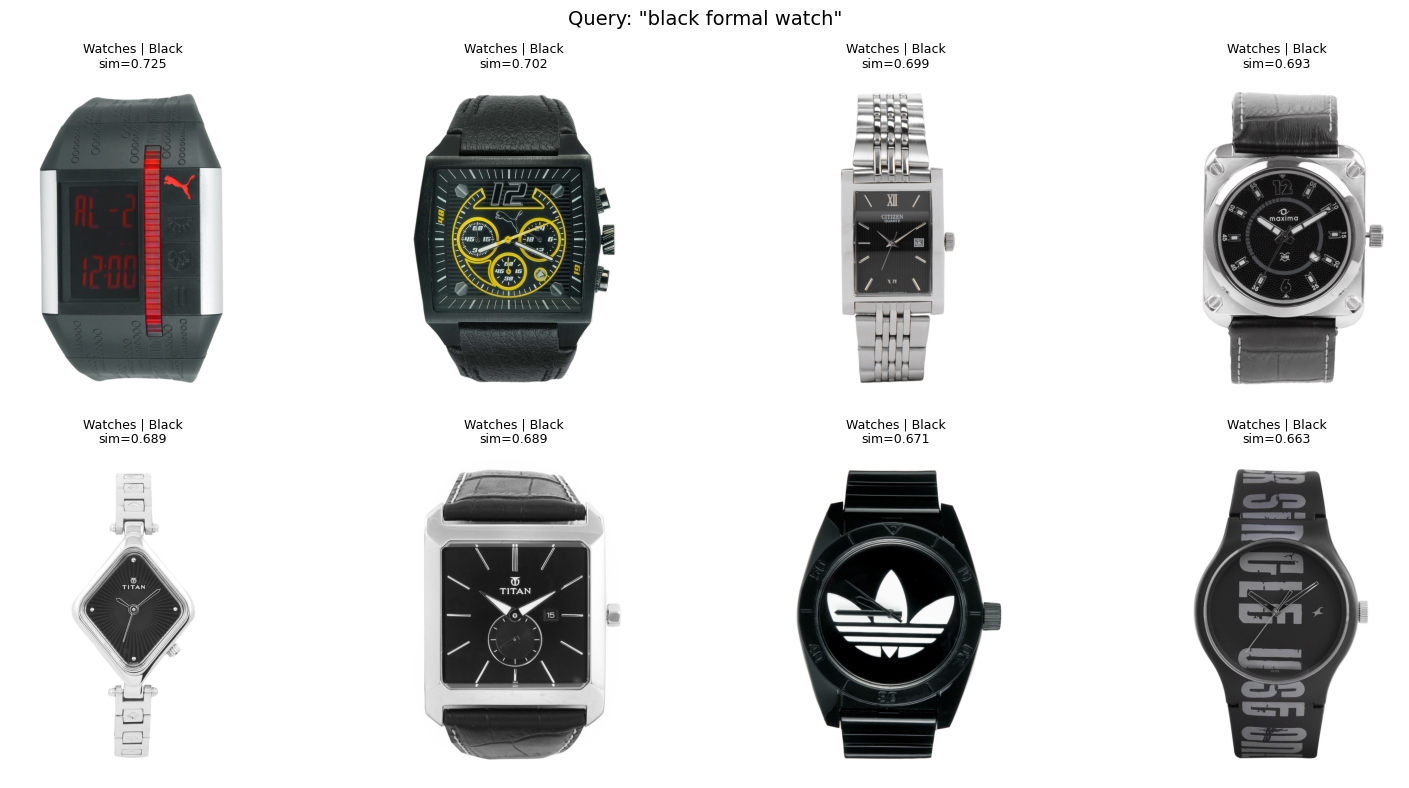

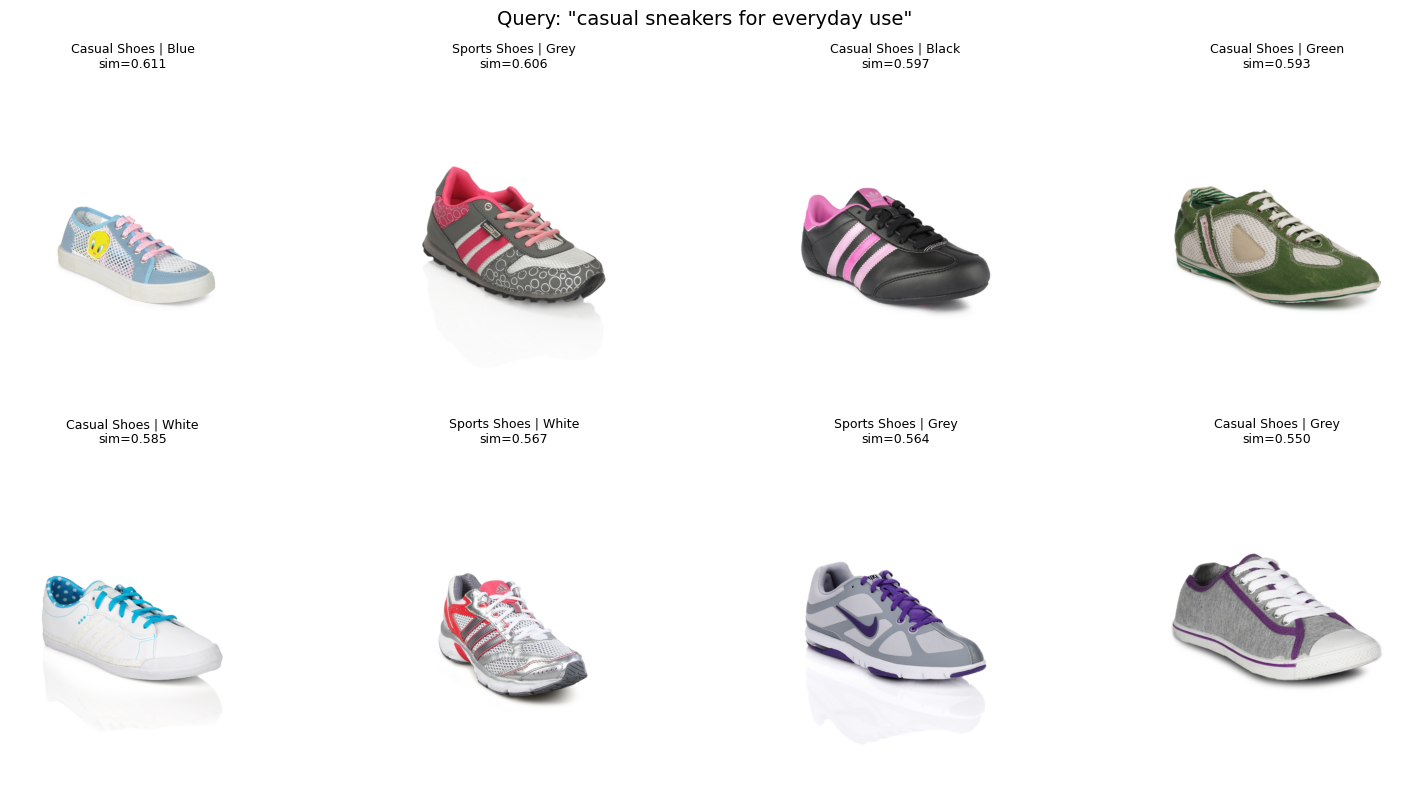

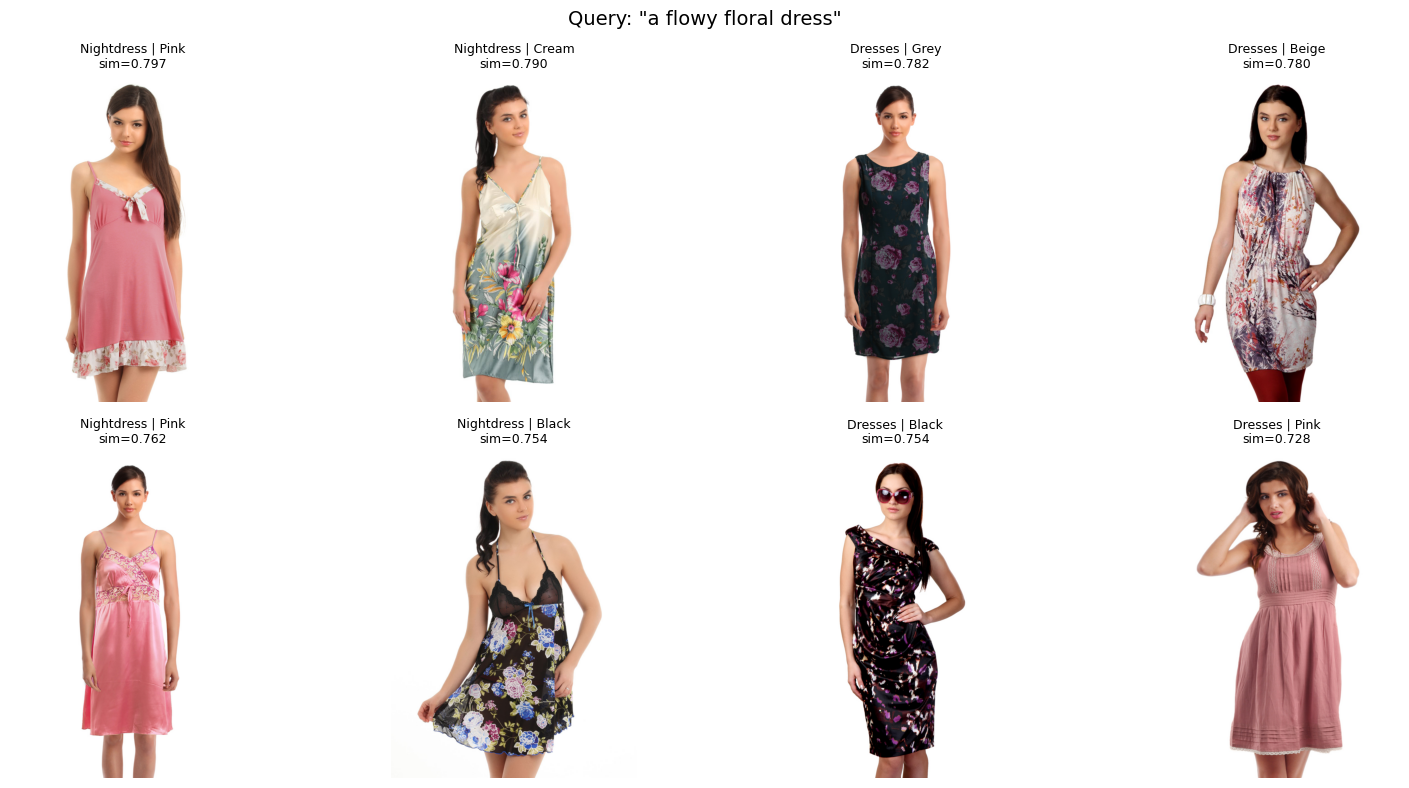

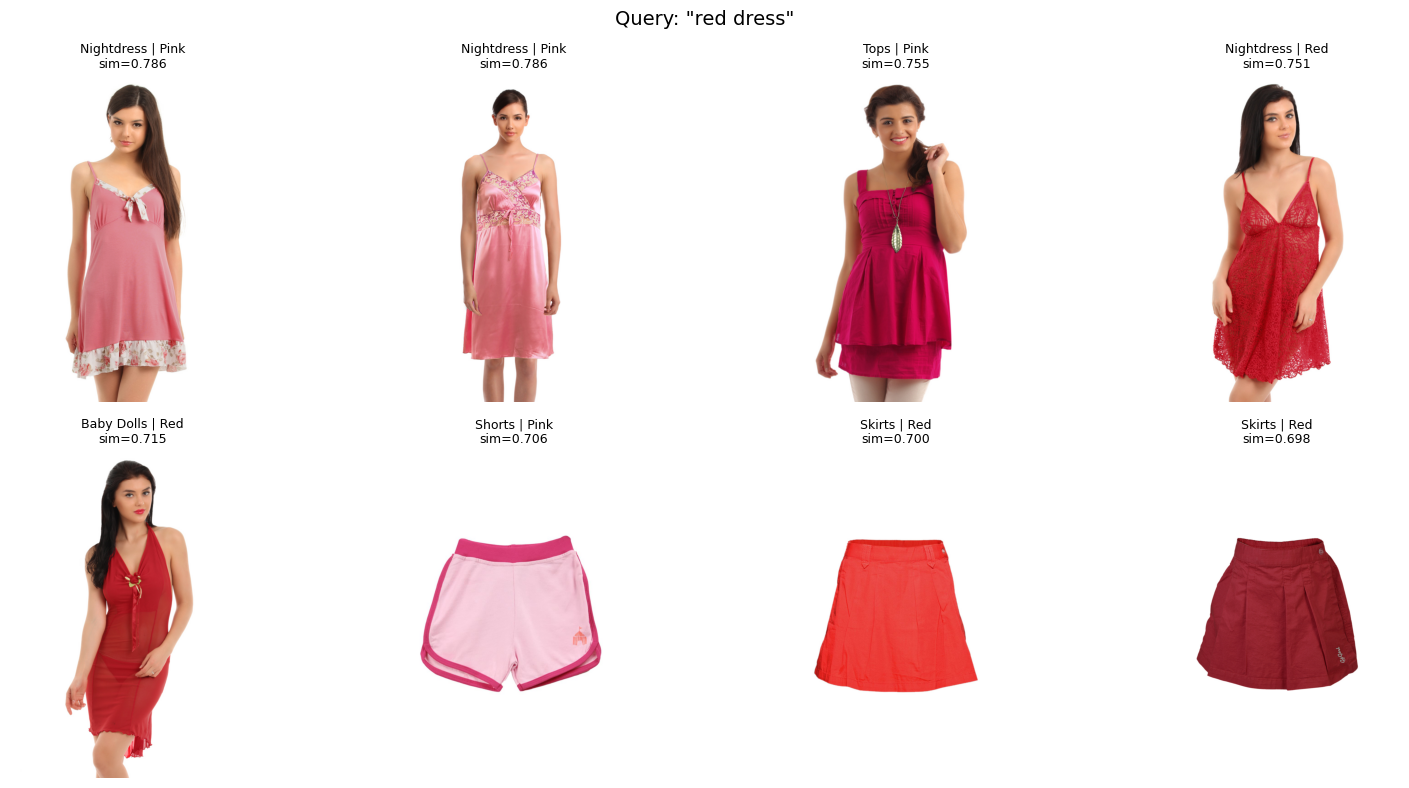

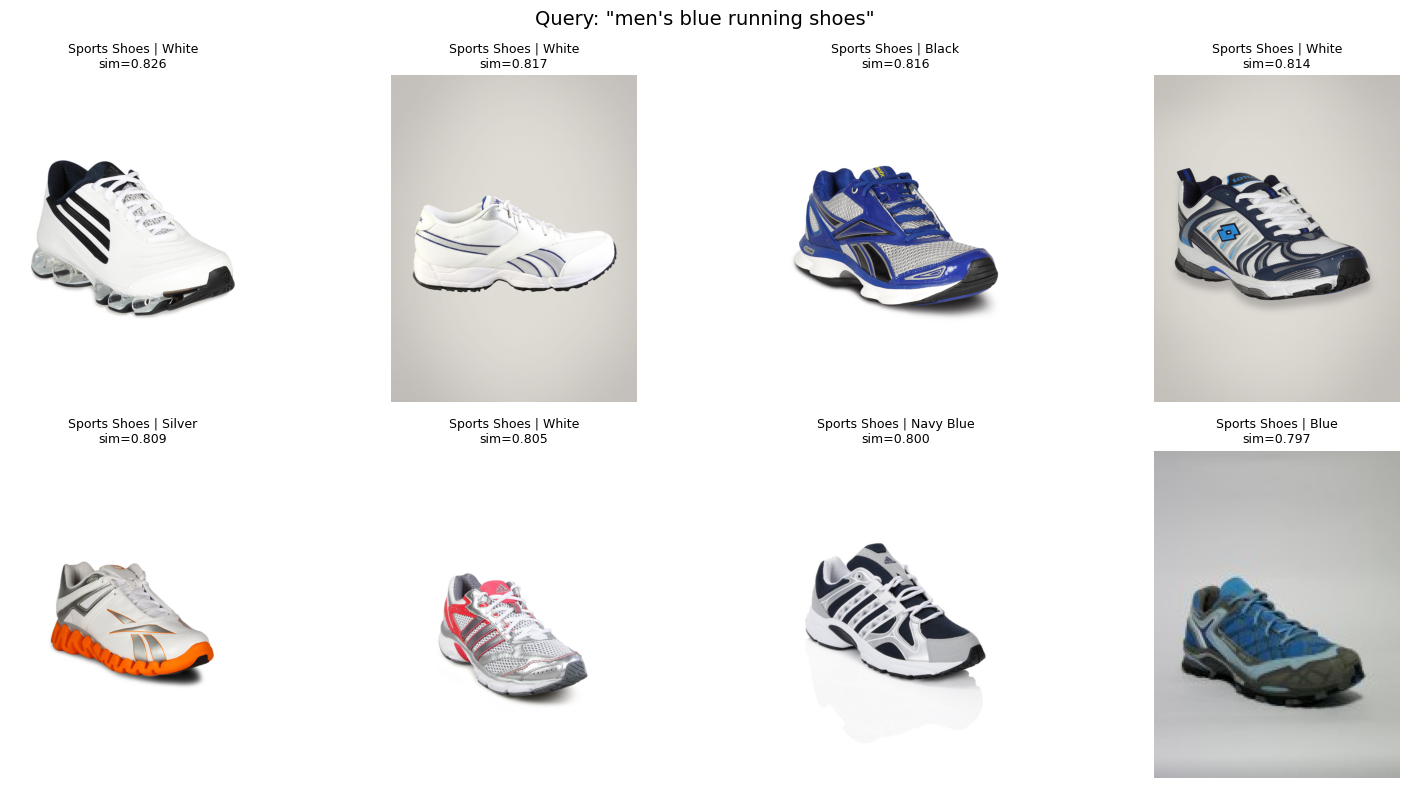

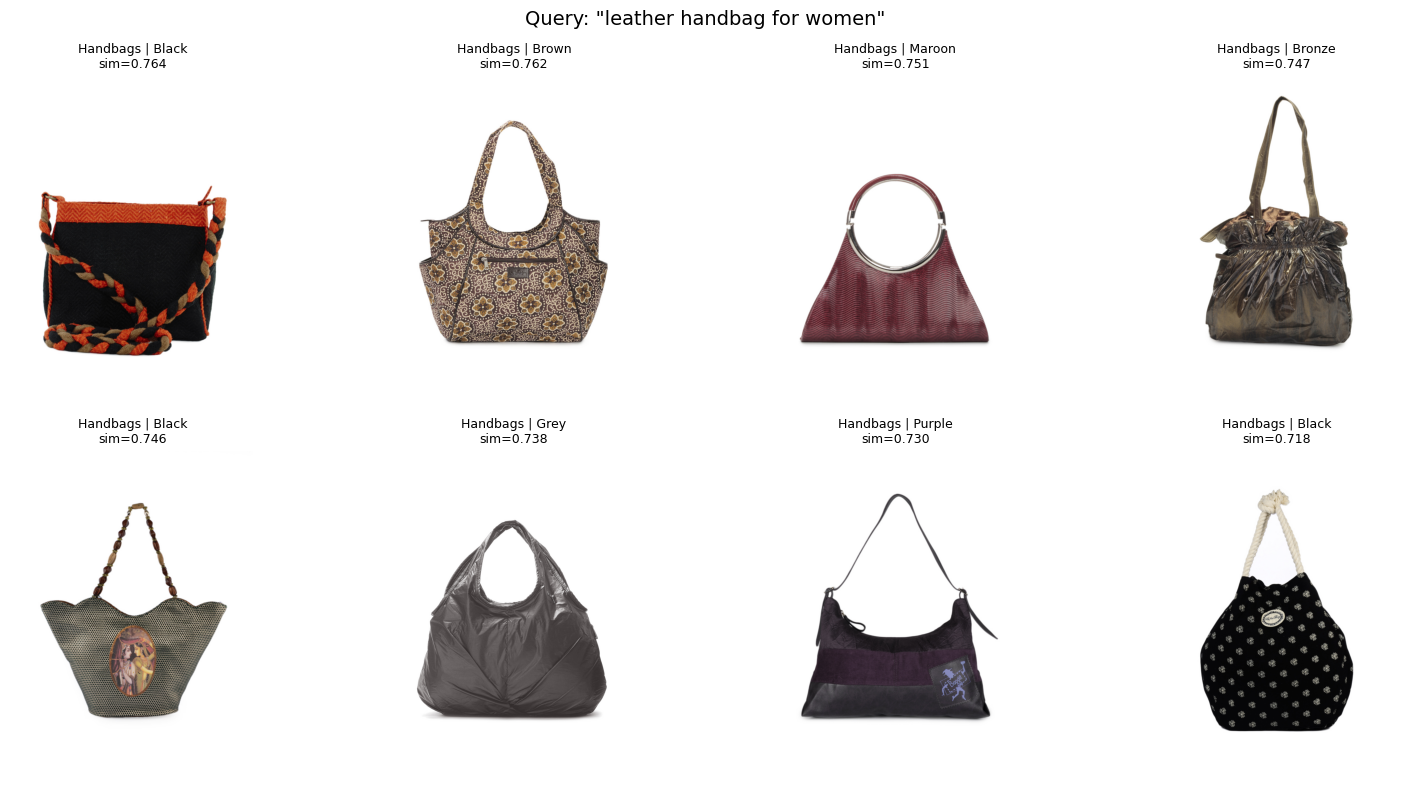

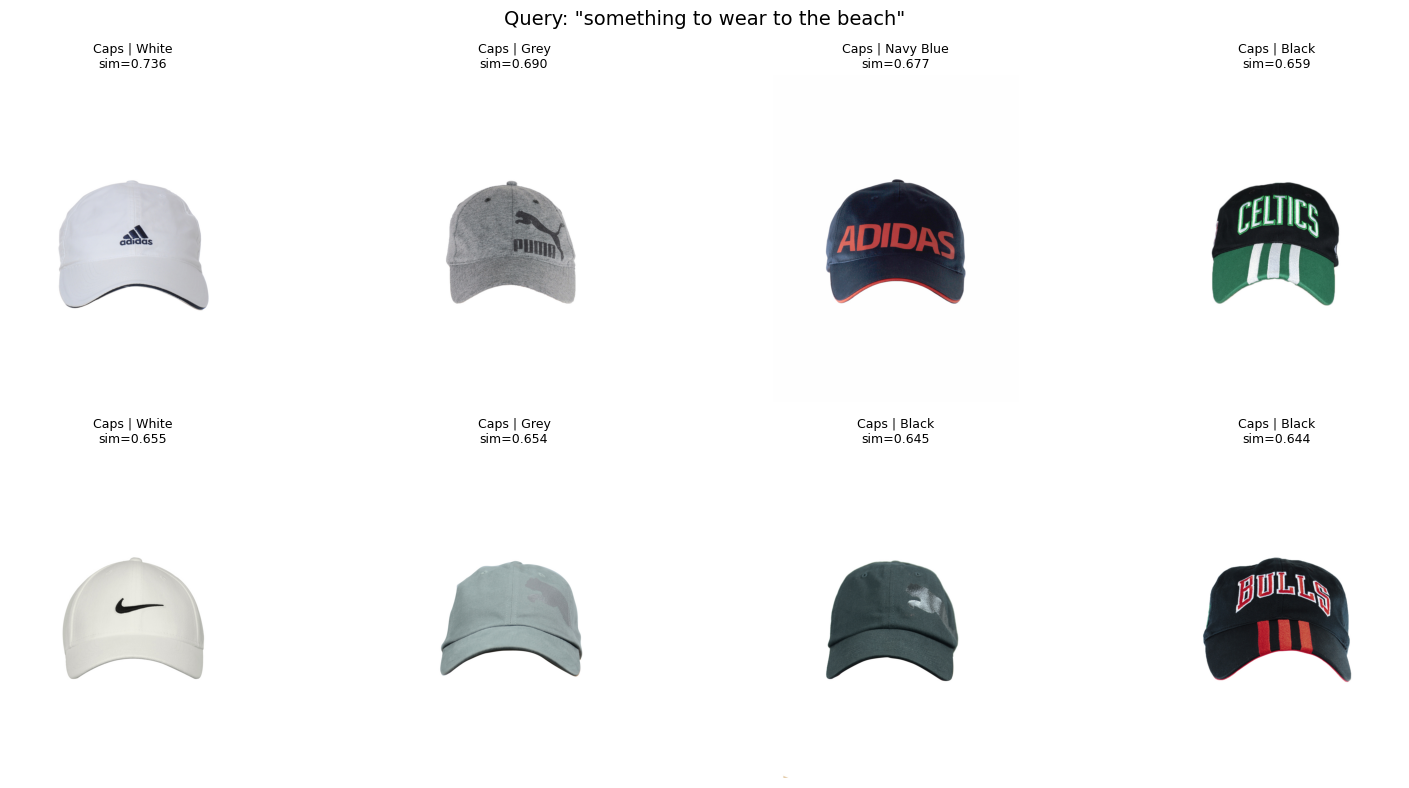

In [13]:
from PIL import Image as PILImage

def search(query, df_unique, img_emb, k=8):
    qe = encode_texts([query])
    sims = (qe @ img_emb.T).flatten()
    top = np.argsort(-sims)[:k]
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for ax, idx in zip(axes.flat, top):
        row = df_unique.iloc[idx]
        img = PILImage.open(IMG_DIR / row['image_path'])
        ax.imshow(img)
        ax.set_title(f'{row["articleType"]} | {row["baseColour"]}\nsim={sims[idx]:.3f}', fontsize=9)
        ax.axis('off')
    fig.suptitle(f'Query: "{query}"', fontsize=14)
    plt.tight_layout()
    plt.show()

for q in ['black formal watch',
          'casual sneakers for everyday use',
          'a flowy floral dress',
          'red dress',
          "men's blue running shoes",
          'leather handbag for women',
          'something to wear to the beach']:
    search(q, val_unique, img_emb)

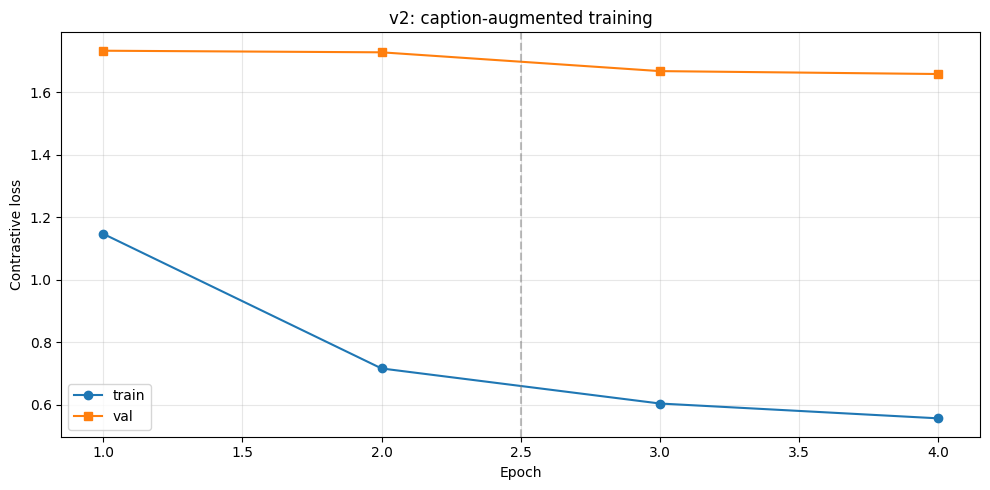

In [14]:
image_encoder.save_weights(CKPT_DIR / 'aug_image_encoder.weights.h5')
text_encoder.save_weights(CKPT_DIR / 'aug_text_encoder.weights.h5')
with open(CKPT_DIR / 'aug_vectorizer_vocab.pkl', 'wb') as f:
    pickle.dump(vectorizer.get_vocabulary(), f)

# Save loss curves
all_train = baseline_hist.history['loss'] + ft_hist.history['loss']
all_val   = baseline_hist.history['val_loss'] + ft_hist.history['val_loss']
phase_change = len(baseline_hist.history['loss'])
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(all_train) + 1), all_train, marker='o', label='train')
plt.plot(range(1, len(all_val) + 1), all_val, marker='s', label='val')
plt.axvline(phase_change + 0.5, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Epoch'); plt.ylabel('Contrastive loss'); plt.legend(); plt.grid(True, alpha=0.3)
plt.title('v2: caption-augmented training')
plt.tight_layout()
plt.savefig(CKPT_DIR / 'aug_loss_curve.png', dpi=120)
plt.show()